In [2]:
import numpy as np
import pyfftw

from IPython.display import Image

# Valid Convolution, Circular Convolution, and Overlap-Add methods to compute Sliding Dot Product

The sliding dot product (SDP) of a query, `Q`, and a time series, `T`, is an array of length `len(T) - len(Q) + 1`, where the $i^{th}$ element is the dot product between `Q` and `T[i:i+len(Q)]`. In the following sections, we will explain how it is related to convolution, and how it can be computed faster when arrays are large.

## Valid Convolution

An easy way to grasp convolution is to understand it via its flip-and-slide form [(See section 4.1.6 of Introduction to Signal Processing by Orfanidis)](https://www.amazon.com/Introduction-Signal-Processing-Sophocles-Orfanidis/dp/0132091720/ref=sr_1_1?dib=eyJ2IjoiMSJ9.KazpLCcWASczX1BqPnOFCPe9I6t9UJQZCCDSfmeVN4Q.eQ6V1-Ht0LQrC95afdw-bar36hTQe1KQD1_ZaOnhpHE&dib_tag=se&qid=1776127943&refinements=p_27%3ASophocles+J.+Orfanidis&s=books&sr=1-1)! The convolution between two finite arrays is calculated when **one array is <u>flipped</u> and slid along the other array. At each time (step), the output sample is obtained by computing the dot product of overlapping elements**.  

The **"valid convolution"** between two arrays is computed by flipping the shorter array and sliding it along the longer array, and computing the dot product when there is a full overlap. Therefore, the SDP between `T` and `Q` is equivalent to the valid convolution between `T` and  `Qr=Q[::-1]`.

**Example:**
<br> 
Suppose `T = [1, 2, 3, 4, 5]` and `Q = [1, 2, 3]`. Their SDP is `[14, 20, 26]`. As explained above, that this is equivalent to the valid convolution between `T = [1, 2, 3, 4, 5]` and `Qr = [3, 2, 1]`.

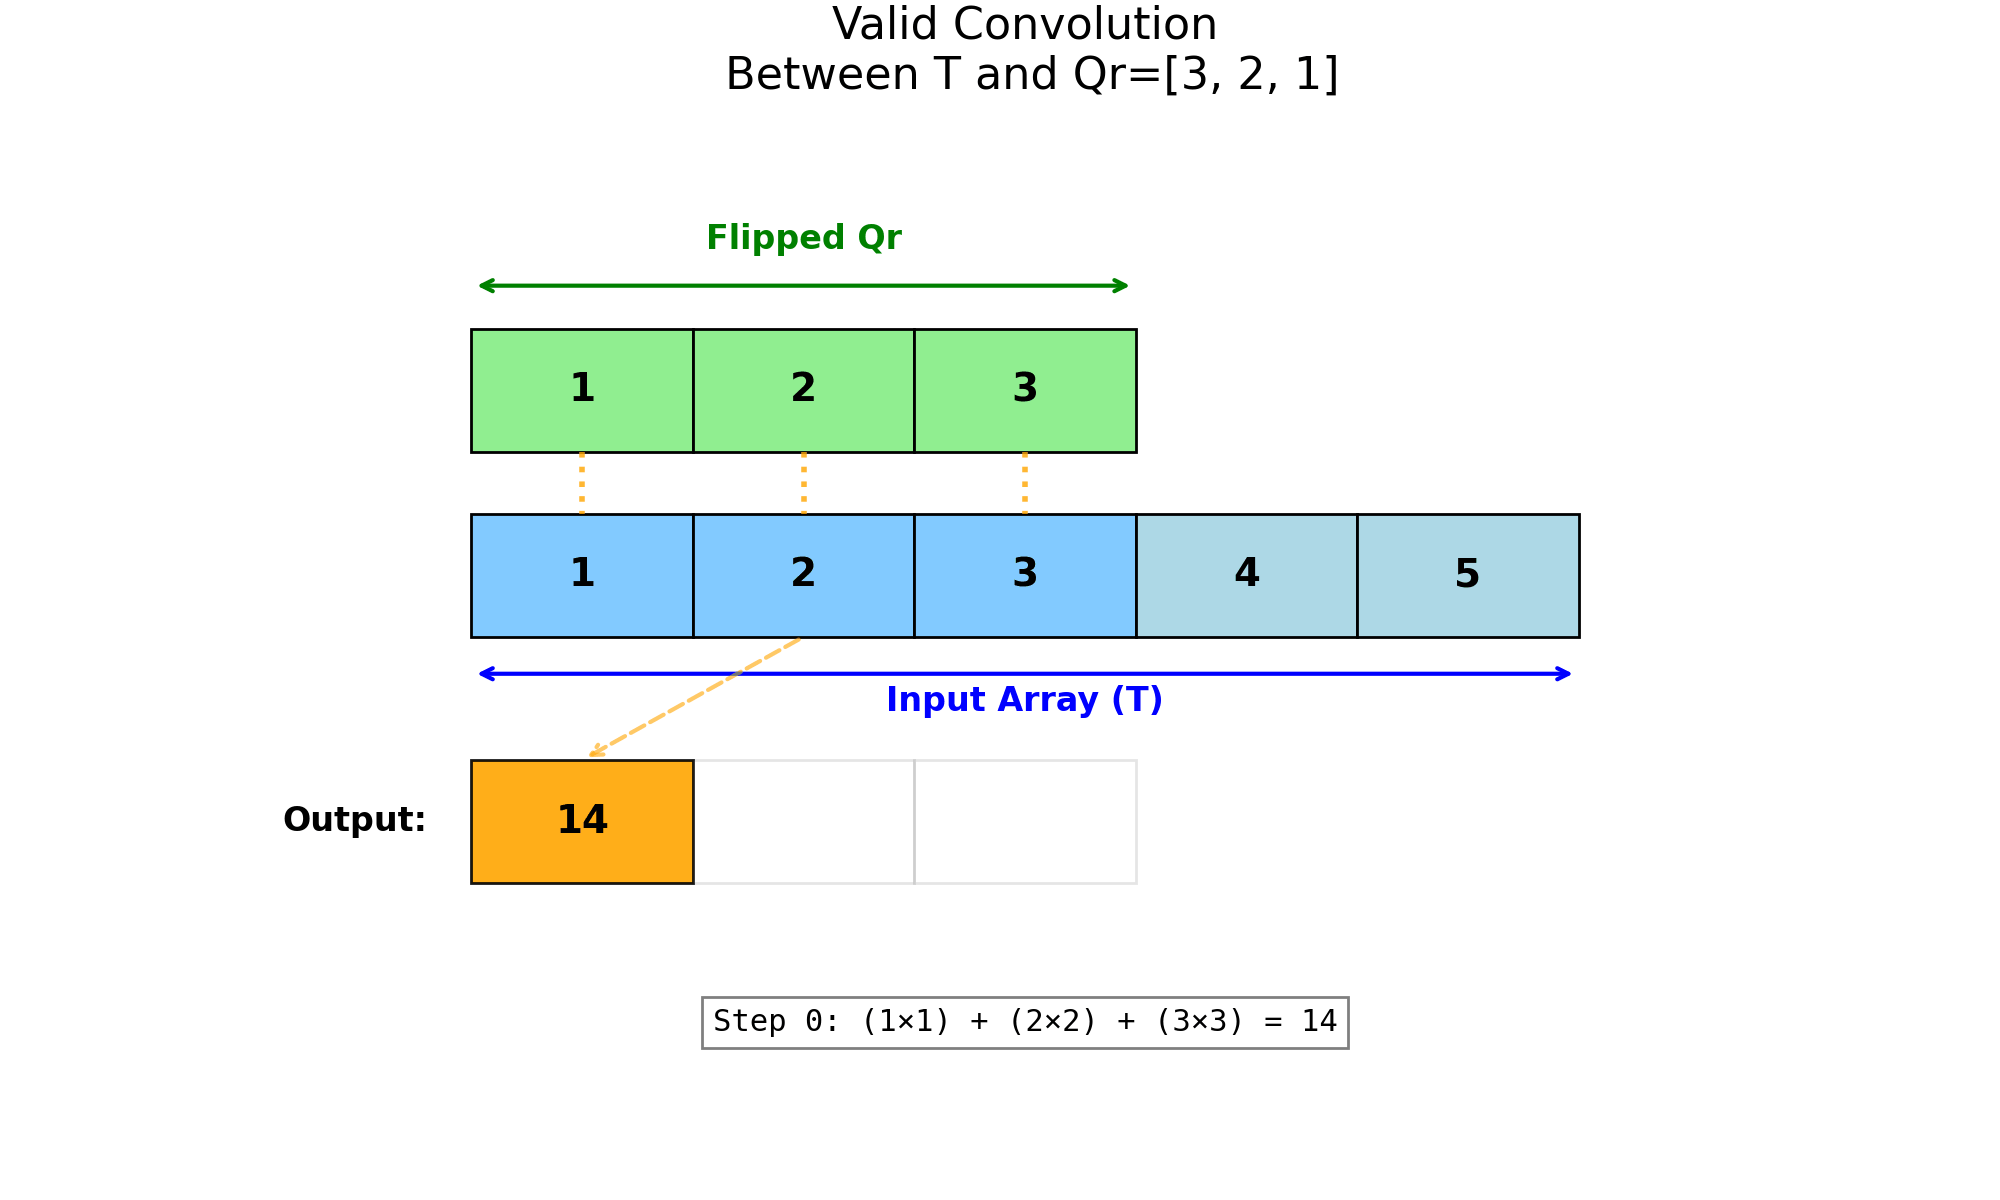

In [2]:
Image(filename='valid_convolution.gif', width=800, height=300)

Notice that `Qr` is <u>flipped</u> and slid along the array `T`. The `Flipped Qr` is the same as `Q`, meaning the valid convolution between `T` and `Qr=Q[::-1]` is the SDP between `T` and `Q`. From this point onwards, we mainly focus on the "valid convolution" between `T` and `Qr`. The time complexity of valid convolution via flip-and-slide form, as shown above, is $O(nm)$, where `n=len(T)` and `m=len(Qr)`. For large arrays, this can be computed faster with the help of `FFT`, which comes into the picture in "circular convolution". But first, let's understand the circular convolution and see how it is related to the valid convolution.

## Circular Convolution

As we will see shortly, the valid convolution can be computed via circular convolution. The circular convolution is [defined as the convolution between two periodic sequences that have the same period 'N'](https://en.wikipedia.org/wiki/Circular_convolution). The output will also be a periodic sequence with the same period as inputs'. Let's revisit the example from the previous section, and compute the circular convolution between `T = [1, 2, 3, 4, 5]` and `Qr=[3, 2, 1]`. Hold on! That cannot happen since their periods do not have the same length! Let's pad `Qr` with zeros till its length becomes the same as `len(T)`. In what follows, we'll compute the ciruclar convolution between `T = [1, 2, 3, 4, 5]` and `Qr_padded=[3, 2, 1, 0, 0]` using the following steps:

1. Flip the `Qr_padded` array, i.e. `[0, 0, 1, 2, 3]`
2. Slide the `flipped Qr_padded` array across `T`, starting from where there is at least one overlapping element
3. For other elements of a sequence, their corresponding elements from the other sequence can be obtained since sequences are periodic

To be more precise, this is only one period of output, and it is called length-N circular convolution, where `N` is the length of the period.

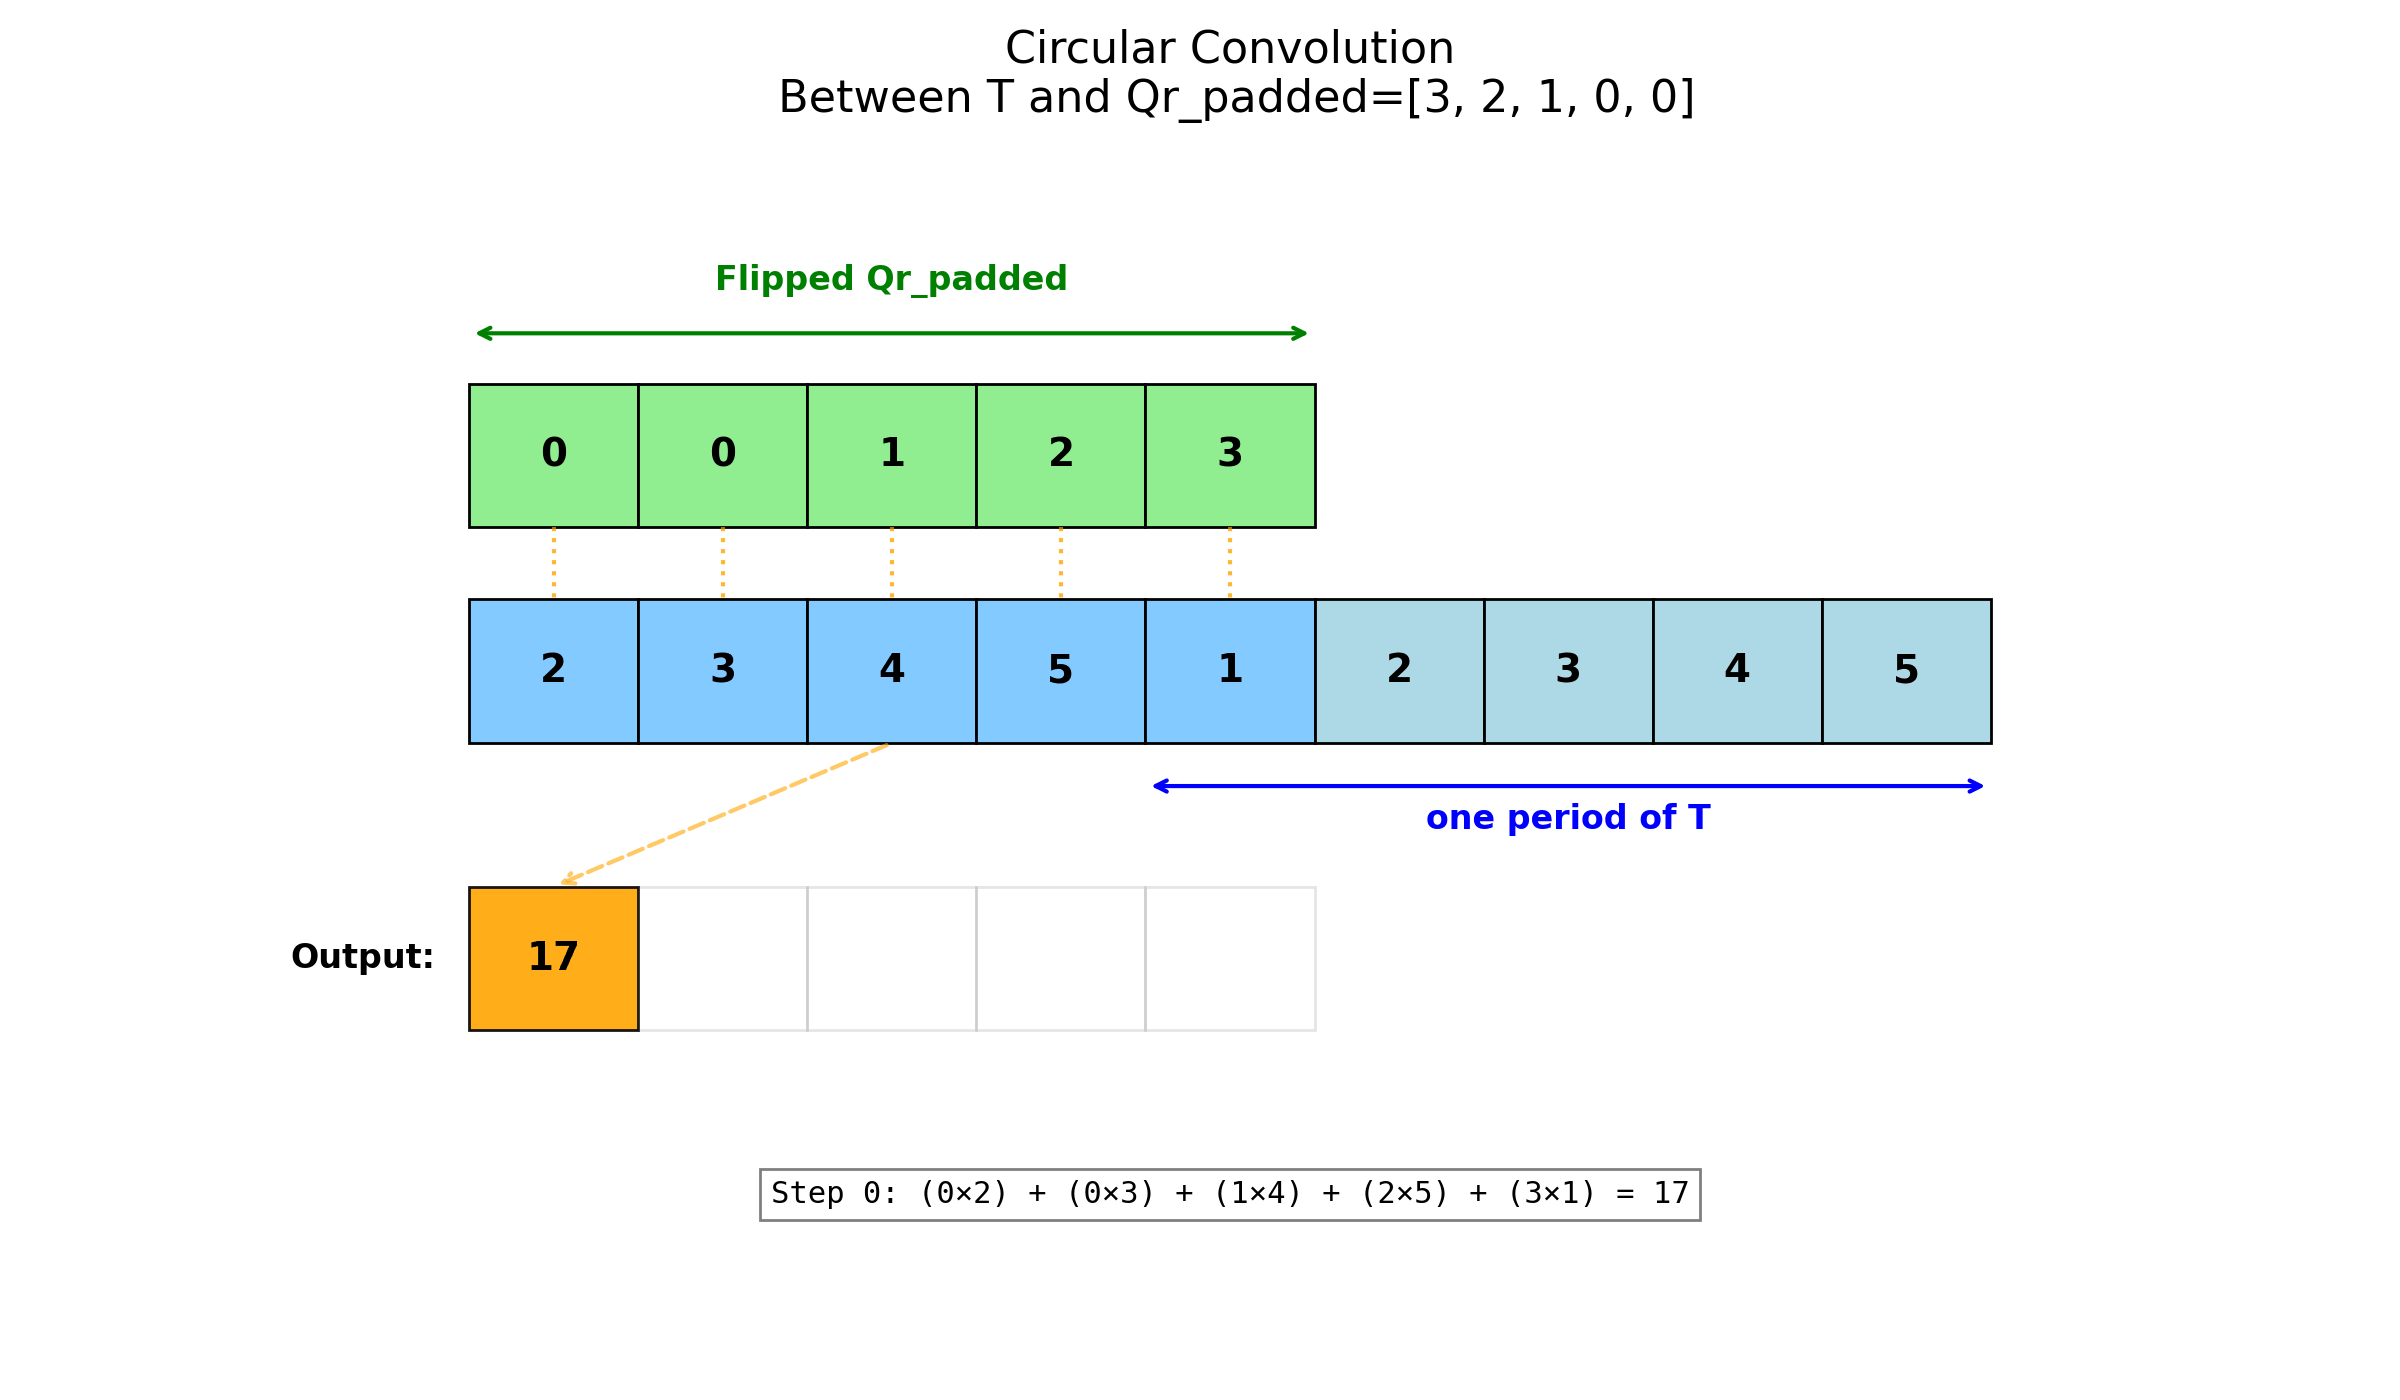

In [3]:
Image(filename='convolution_annotated_circular.gif', width=800, height=300)

The animation above shows the length-5 circular convolution in time domain. Once calculated, the valid convolution between `T` and `Qr` can be obtained by getting the `slice(len(QR)-1, len(T))` of it.

The circular convolution can be computed in the frequency domain as follows: `IFFT(FFT(T) * FFT(Qr_padded))`. This allows us to compute the circular convolution with $O(nlog(n))$ time complexity. This means the valid convolution can be computed with $O(nlog(n))$ via this approach, which is faster than $O(nm)$ for large value of `m=len(Qr)`.

In [4]:
T = np.array([1, 2, 3, 4, 5]).astype(np.float64)
Qr_paded = np.array([3, 2, 1, 0, 0]).astype(np.float64)

out = np.fft.ifft(np.fft.fft(T) * np.fft.fft(Qr_paded))
out

array([17.+0.j, 13.+0.j, 14.+0.j, 20.+0.j, 26.+0.j])

and we can get the valid convolution using the `slice(2, 5)`, which gives `[14, 20, 26]`

## Overlap-add Convolution

So far, we learned that we can use (FFT-based) circular convolution between `T` and `Qr_padded` to compute the valid convolution between  `T` and `Qr`. It turns out that there is a way to achieve the valid convolution on large arrays by performing several (independent) circular convolutions on (non-overlapping) chunks of the arrays. The [overlap-add method](https://en.wikipedia.org/wiki/Overlap–add_method) is a common approach that can make the computation faster if the chunk size is chosen optimally but let's set that aside for now and simply focus on how the method works.

**Example:**
<br>
`T = [1, 2, 3, ..., 10]` and `Qr = [3, 2, 1]`.  Their "valid convolution" is `[14, 20, 26, 32, 38, 44, 50, 56]`. In circular convolution, `Qr` is padded with zeros till its length becomes the same as `len(T)`. In **overlap-add method**, however, we first break `T` into smaller NON-overlapping chunks. For instance, let's consider `chunk_size=5`. Therefore, `T` can be chunked into `T1=[1, 2, 3, 4, 5]` and `T2=[6, 7, 8, 9, 10]`. Notice that we are losing the subsequences `{4, 5, 6}` and `{5, 6, 7}` since the elements of each of those two subsequences do not sit on a single chunk. To handle those cases, each chunk needs to be padded with `len(Qr)-1` zeros so that the `overlap-add` method can correctly re-construct the "valid convolution" output at the end.

<div class="alert alert-block alert-info">
<b> &#9432; Why does each chunk need to be padded with `len(Qr)-1` zeros?</b>

<br> Suppose `T1` and `T2` are two adjacent NON-overlapping chunks from the array `T`, and let the query length be `m = len(Qr)`. Consider the subsequence `{T1[-1], T2[0], T2[1], ..., T2[m-2]}` from `T`, whose starting element is the last element of `T1`, and all the remaining `m-1` elements are in `T2`. Recall that convolution flips the query. So, the convolution computes the dot product between each subsequence of `T` and `Qr[::-1]==Q`. The dot product for that particular subsequence is: `T1[-1]*Q[0] + T2[0]*Q[1] + ... + T2[m-2]*Q[m-1]`. The key idea is that we want to reconstruct this value using two independent circular convolutions: one circular convolution depends on `C1` and another one depends on `T2`. 

We can split the aforementioned expression into two parts:

`(T1[-1]*Q[0] + 0 + ... + 0) + (0 + T2[0]*Q[1] + ... + T2[m-2]*Q[m-1])`

The first term can be rewritten as `T1[-1]*Q[0] + 0*Q[1] + ... + 0*Q[m-1]`, which is equivalent to the dot product between `{T1[-1], 0, 0, ..., 0}` and `Q`. This shows why we need to pad chunk with `m-1` trailing zeros. Similarly, the second term can be written as `0*Q[0] + T2[0]*Q[1] + ... + T2[m-2]*Q[m-1]`, which is equivalent to the dot product between `{0, T2[0], ..., T2[m-2]}` and `Q`.
</div>

* T1_padded = [1, 2, 3, 4, 5, 0, 0]
* T2_padded = [6, 7, 8, 9, 10, 0, 0] 

We now calculate the circular convolution between each padded chunk with length `chunk_size + (len(Qr) - 1)` and `Qr_padded`, which is `Qr` but padded with zeros till its length becomes equal to `chunk_size + len(Qr) - 1`. In this example: `Qr_padded = [3, 2, 1, 0, 0, 0, 0]`

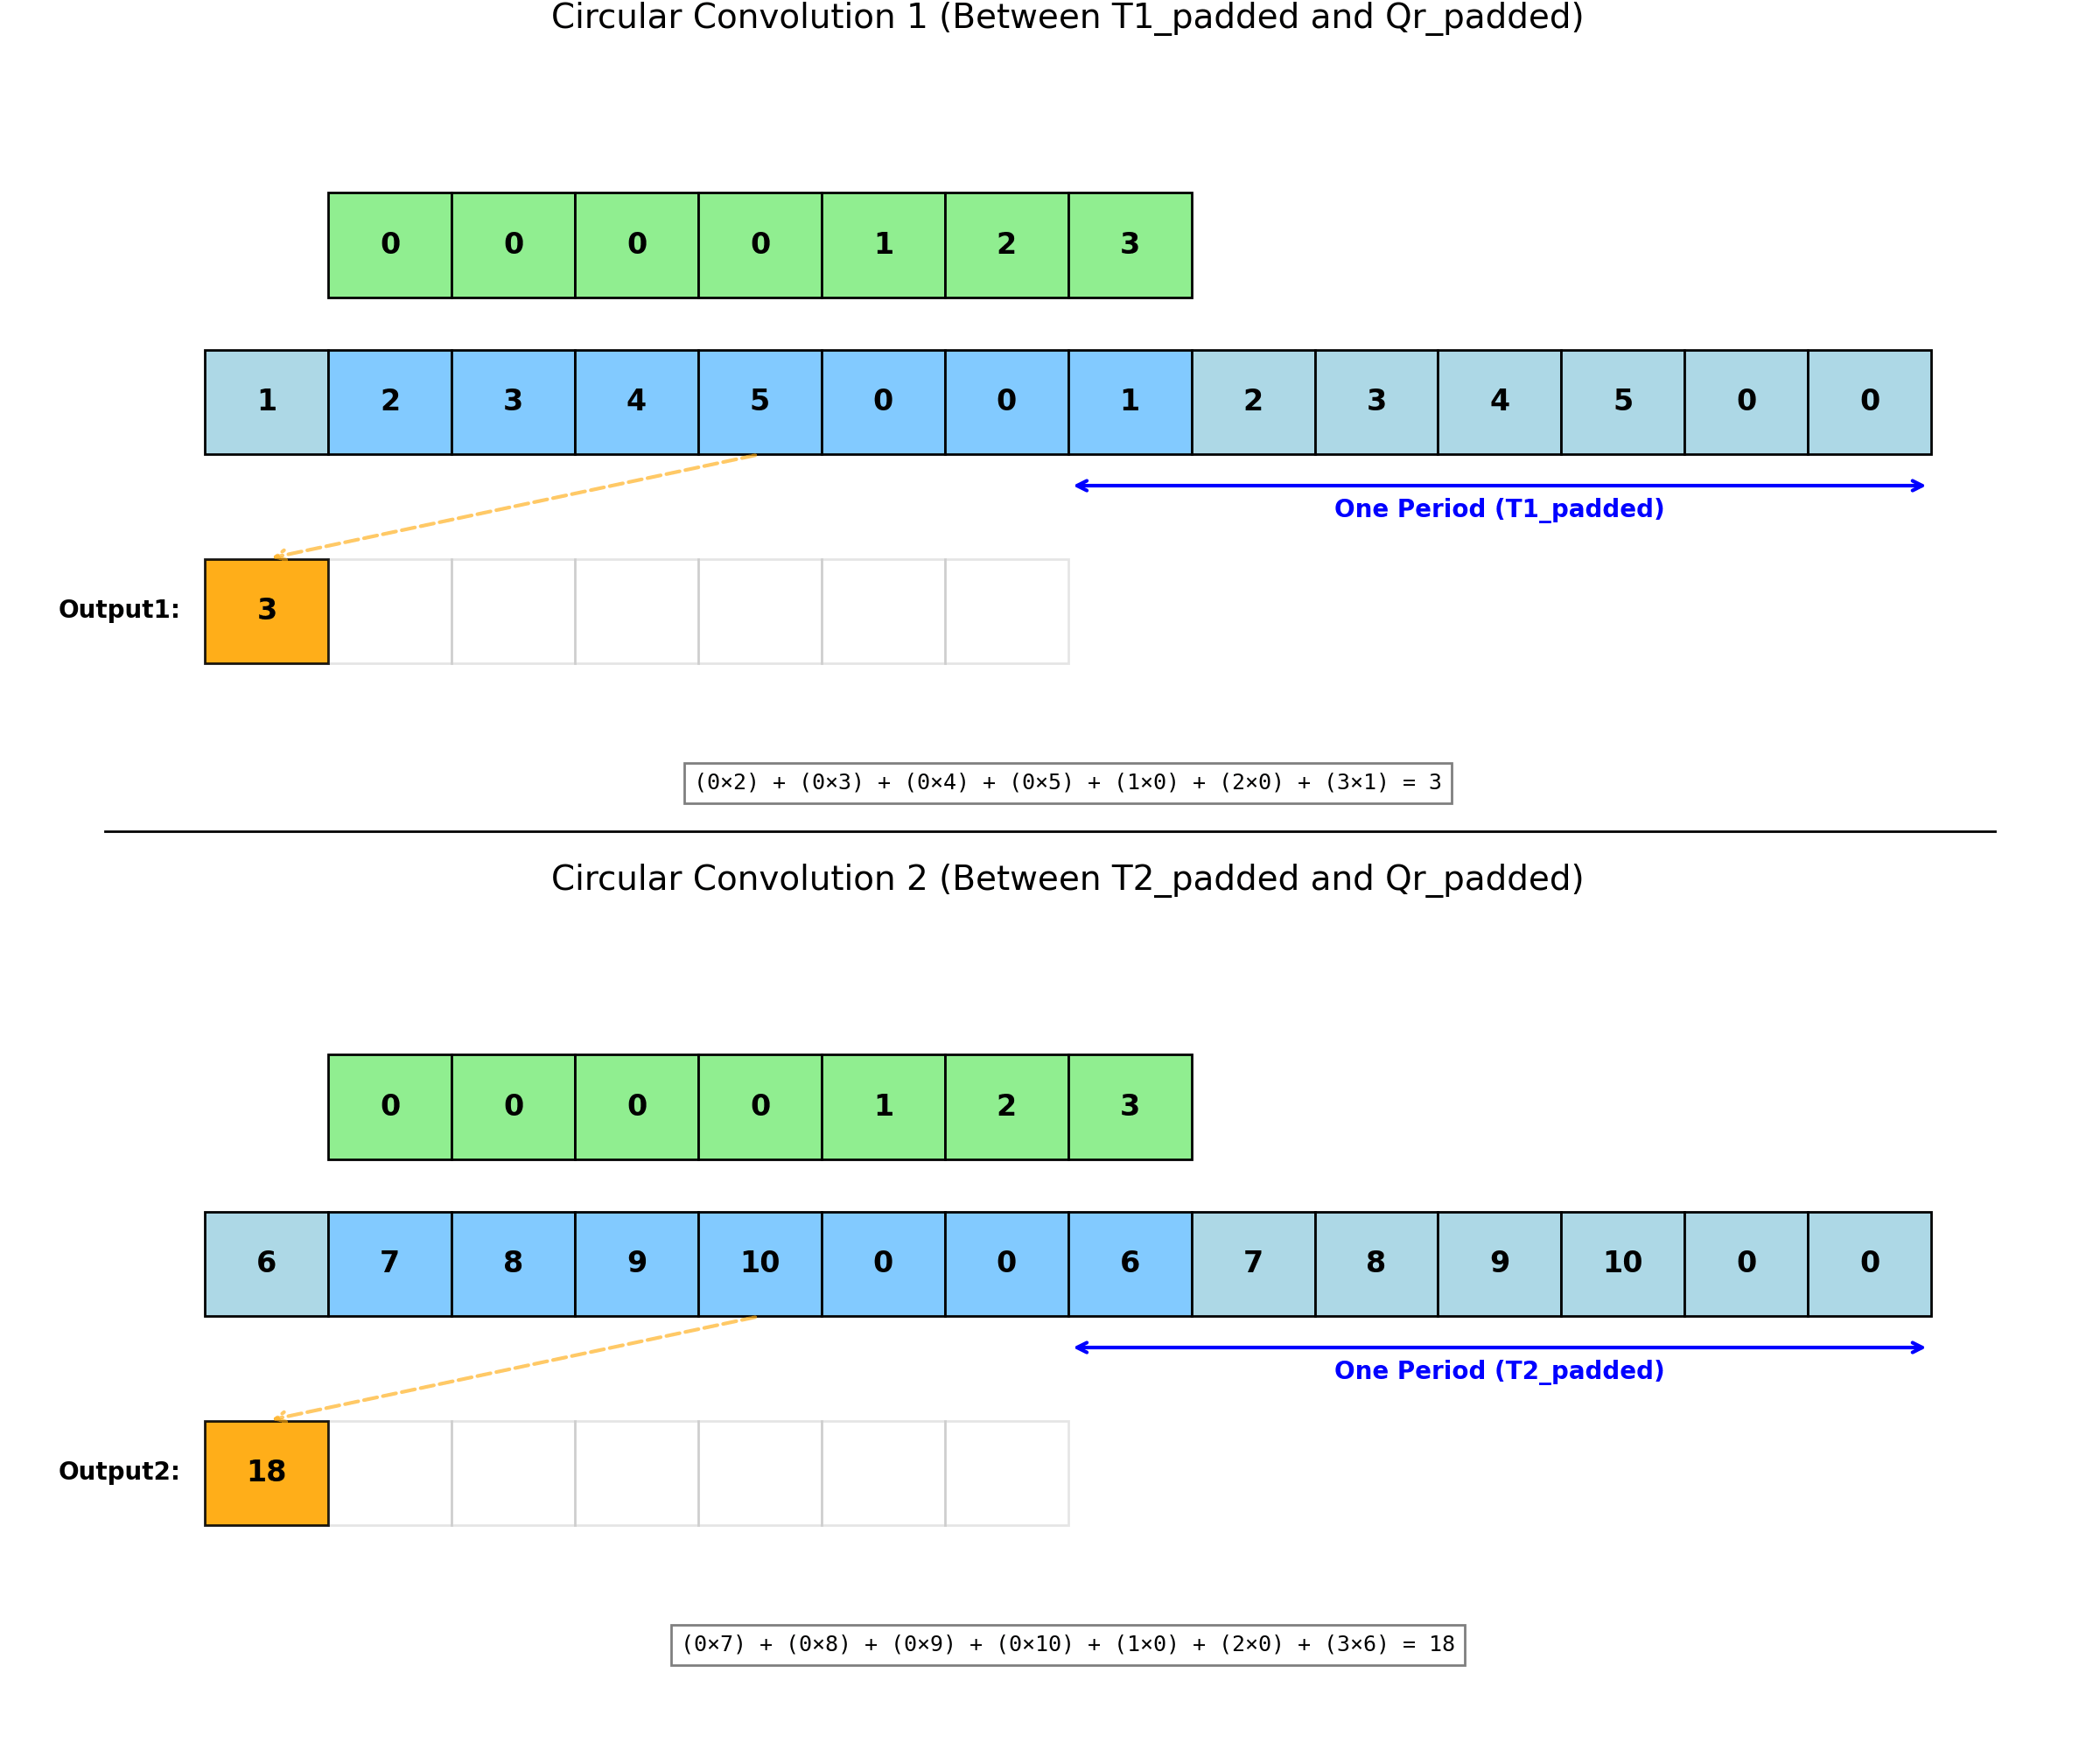

In [5]:
Image(filename='dual_convolution.gif', width=800, height=300)

Once the circular convolutons for all (padded) chunks are computed, we can combine(overlap) the outputs by adding the `m-1` elements at the tail of the each chunk's output to the `m-1` elements at the head of the next chunk's output. This is because chunking `T` into smaller arrays results in losing the subsequences `{4, 5, 6}`, and `{5, 6, 7}`, and therefore we need to add the tail of the first output to the head of the second output to recover the dot product for those cases.

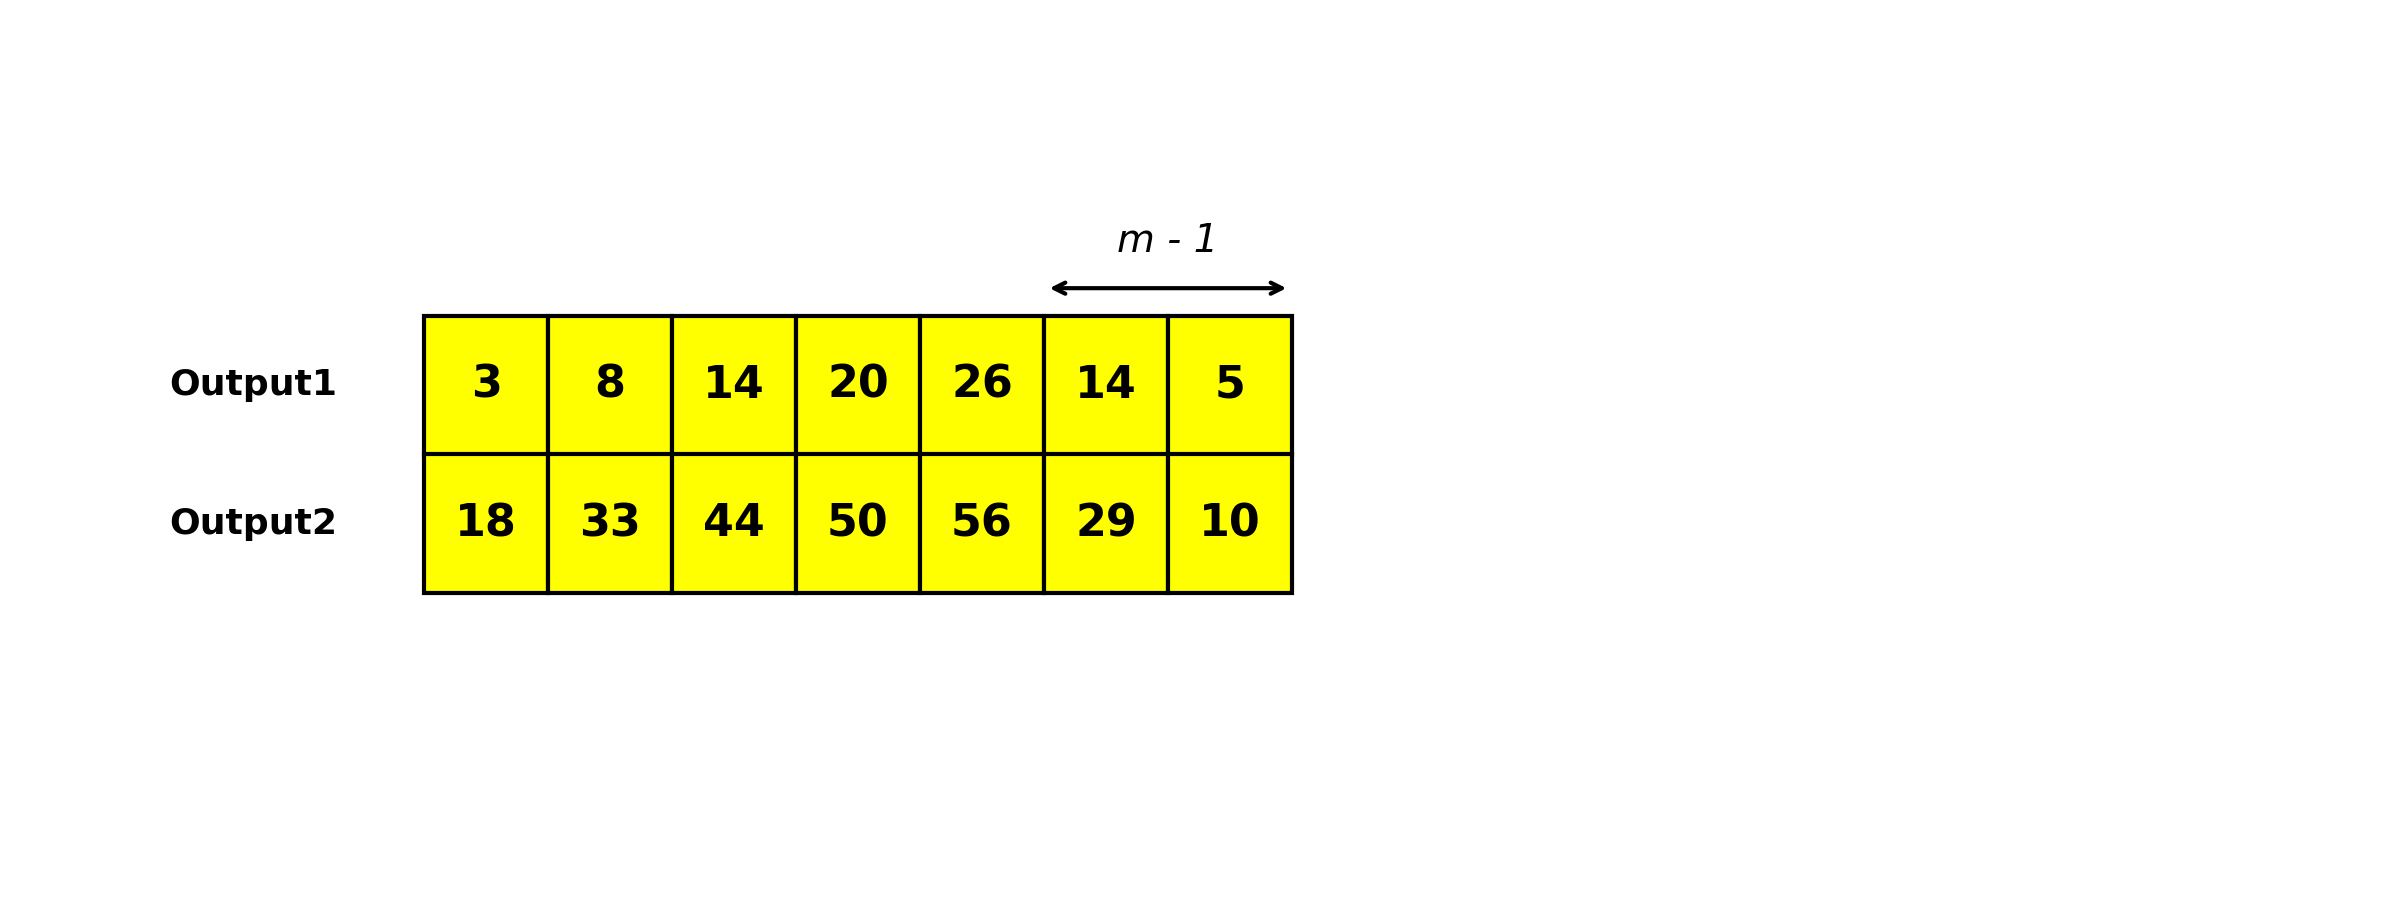

In [6]:
Image(filename='array_merge_annotated.gif', width=800, height=300)

## Bonus: Normalization of forward/ backward Fourier Transforms 

(R)FFT and I(R)FFT are implemented in a way that:

* `IFFT(FFT(x)) = x`

* `IRFFT(RFFT(x)) = x`

By convention, (R)FFT is scaled by `1` (i.e. no scaling), and I(R)FFT is scaled by `1 / len(x)`. Several python libraries like numpy, scipy, and pyfftw follow similar convention, i,e. their forward Fourier Transform has no normalization and their backward Fourier Transform scales the tranformation by `1/len(x)`. This default behaviour results in achieving the correct outcome for circular convolution when the computation is done in the frequency domain. This default behaviour also ensures that `IFFT(FFT(x)) == x` and `IRFFT(RFFT(x)) == x`.

`pyfftw.FFTW` class provides support for the method `execute`, which performs (forward or backward) Fourier Transform but has no normalization. While one can use this thin wrapper to get a performance boost, they should be careful regarding the normalization part and understand whether that needs to be applied or not. In the following examples, we've used numpy's (i)rfft and pyfftw's (i)rfft to better demonstrate this matter.

In [1]:
# Example 1
# Use numpy to check IRFFT(RFFT(x)) == x

import numpy as np


n_T = 4
T = np.random.rand(n_T)
R = np.fft.rfft(T)
IR = np.fft.irfft(R)
np.testing.assert_allclose(T, IR, rtol=1e-5, atol=1e-8)

In [2]:
# Example 2
# Use pyfftw to check IRFFT(RFFT(x)) == x

import numpy as np
import pyfftw


n_T = 4
real_view = pyfftw.empty_aligned(n_T, dtype="float64")
complex_view = pyfftw.empty_aligned(n_T//2 + 1, dtype="complex128")
planning_flag = "FFTW_ESTIMATE"
n_threads = 1

rfft_obj = pyfftw.FFTW(
    input_array=real_view,
    output_array=complex_view,
    direction="FFTW_FORWARD",
    flags=(planning_flag,),
    threads=n_threads,
)

irfft_obj = pyfftw.FFTW(
    input_array=complex_view,
    output_array=real_view,
    direction="FFTW_BACKWARD",
    flags=(planning_flag,),
    threads=n_threads,
)

T = np.random.rand(n_T)
real_view[:] = T
rfft_obj()
R = rfft_obj.output_array

complex_view[:] = R.copy()
irfft_obj()
# irfft_obj.output_array contains the IRFFT(RFFT(T))

np.testing.assert_allclose(T, irfft_obj.output_array, rtol=1e-5, atol=1e-8)

In [3]:
# Example 3
# Use pyfftw to check IRFFT(RFFT(x)) == x 
# However, this time, we will use the thin wrapper "execute"... 
# ... that does Fourier transform only without any scaling.

import numpy as np
import pyfftw


n_T = 4
real_view = pyfftw.empty_aligned(n_T, dtype="float64")
complex_view = pyfftw.empty_aligned(n_T//2 + 1, dtype="complex128")
planning_flag = "FFTW_ESTIMATE"
n_threads = 1

rfft_obj = pyfftw.FFTW(
    input_array=real_view,
    output_array=complex_view,
    direction="FFTW_FORWARD",
    flags=(planning_flag,),
    threads=n_threads,
)

irfft_obj = pyfftw.FFTW(
    input_array=complex_view,
    output_array=real_view,
    direction="FFTW_BACKWARD",
    flags=(planning_flag,),
    threads=n_threads,
)

T = np.random.rand(n_T)
real_view[:] = T
rfft_obj.execute()
R = rfft_obj.output_array

complex_view[:] = R.copy()
irfft_obj.execute()  # gives un-normalized fourier tranformation

scaling_factor = T / irfft_obj.output_array
print("Scaling factor:", scaling_factor)

Scaling factor: [0.25 0.25 0.25 0.25]


As observed, the thin wrapper `execute` in pyfftw does not noramlize the backward fourier tranform, and the scaling factor is `0.25`, which is $\frac{1}{n\_T}$. Therefore, in circular convolution, users need to scale the input or output arrays by `1/n_T` if they use `pyfftw.execute` for computing the backward fourier transform.